## **Pipeline**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
print("PyTorch Version : ",torch.__version__)

PyTorch Version :  2.10.0+cu128


In [ ]:
import transformers
from transformers import AutoTokenizer
from transformers import AutoConfig
from math import sqrt

In [ ]:
print("Transformers Version : ",transformers.__version__)

Transformers Version :  5.0.0


In [ ]:
model_ckpt = "bert-base-uncased"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
config = AutoConfig.from_pretrained(model_ckpt)

In [ ]:
print("Model Configurations : \n",config)

Model Configurations : 
 BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
config.hidden_size = 256
config.num_attention_heads = 8
config.num_hidden_layers = 4
config.intermediate_size = 1024
config.hidden_dropout_prob = 0.1
config.num_labels = 2

In [ ]:
print("New Model Configurations : \n",config)

New Model Configurations : 
 BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 256,
  "initializer_range": 0.02,
  "intermediate_size": 1024,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 8,
  "num_hidden_layers": 4,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



### **Scaled Dot Product**

In [ ]:
def scaled_dot_product(query, key, value):
    dim_k = key.size(-1)
    d_k = sqrt(dim_k)
    scores = torch.bmm(query,key.transpose(1, 2)) / d_k
    weights = F.softmax(scores,dim = -1)
    attention = torch.bmm(weights,value)

    return attention

### **Single Head Attention**

In [ ]:
class AttentionHead (nn.Module) :
  def __init__ (self,embd_dim,head_dim) :
    super().__init__ ()
    self.q = nn.Linear(embd_dim,head_dim)
    self.k = nn.Linear(embd_dim,head_dim)
    self.v = nn.Linear(embd_dim,head_dim)

  def forward (self,hidden_state) :
    attention = scaled_dot_product(self.q(hidden_state),
                                   self.k(hidden_state),
                                   self.v(hidden_state))
    return attention

### **MultiHead Attention**

In [ ]:
class MultiHeadAttention (nn.Module) :
  def __init__ (self,config) :
    super().__init__ ()
    embd_dim = config.hidden_size
    num_heads = config.num_attention_heads
    head_dim = embd_dim // num_heads

    self.heads = nn.ModuleList([
        AttentionHead(embd_dim,head_dim) for _ in range(num_heads)
    ])
    self.output_layer = nn.Linear(embd_dim,embd_dim)

  def forward (self,hidden_state) :
    x = torch.cat([h(hidden_state) for h in self.heads],
                  dim = -1)
    attention = self.output_layer(x)
    return attention

### **Feed Forward Layer**

In [ ]:
class FeedForwardLayer (nn.Module) :
  def __init__ (self,config) :
    super().__init__ ()
    self.layer_1 = nn.Linear(config.hidden_size,config.intermediate_size)
    self.layer_2 = nn.Linear(config.intermediate_size,
                             config.hidden_size)

    self.gelu = nn.GELU()
    self.dropout = nn.Dropout(config.hidden_dropout_prob)

  def forward (self,x) :
    x = self.layer_1(x)
    x = self.gelu(x)
    x = self.layer_2(x)
    x = self.dropout(x)
    return x

### **Single Transformer Encoder**

In [ ]:
class TransformerEncoderLayer (nn.Module) :
  def __init__ (self,config) :
    super().__init__ ()
    self.layer_norm_1 = nn.LayerNorm(config.hidden_size)
    self.layer_norm_2 = nn.LayerNorm(config.hidden_size)

    self.attention = MultiHeadAttention(config)
    self.feed_forward = FeedForwardLayer(config)

  def forward (self,x) :
    hidden_state = self.layer_norm_1(x)
    x = x + self.attention(hidden_state)
    x = x + self.feed_forward(self.layer_norm_2(x))
    return x

### **Embeddings**

In [ ]:
class Embeddings (nn.Module) :
  def __init__ (self,config) :
    super().__init__ ()
    self.token_embeddings = nn.Embedding(config.vocab_size,
                                         config.hidden_size)
    self.position_embeddings = nn.Embedding(config.max_position_embeddings,
                                            config.hidden_size)
    self.layer_norm = nn.LayerNorm(config.hidden_size)
    self.dropout = nn.Dropout(config.hidden_dropout_prob)

  def forward (self,input_ids) :
    seq_length = input_ids.size(1)
    position_ids = torch.arange(seq_length,
                                dtype = torch.long, device = input_ids.device).unsqueeze(0)

    token_embeddings = self.token_embeddings(input_ids)
    position_embeddings = self.position_embeddings(position_ids)

    embeddings = token_embeddings + position_embeddings
    embeddings = self.layer_norm(embeddings)
    embeddings = self.dropout(embeddings)
    return embeddings

### **Transformer Encoder**

In [ ]:
class TransformerEncoder (nn.Module) :
  def __init__ (self,config) :
    super().__init__()
    self.embeddings = Embeddings(config)
    self.layers = nn.ModuleList([
        TransformerEncoderLayer(config)
        for _ in range(config.num_hidden_layers)
    ])

  def forward (self,input_ids) :
    x = self.embeddings(input_ids)
    for layer in self.layers :
      x = layer(x)
    return x

### **Classification Head**

In [ ]:
class TransformerForSequenceClassification (nn.Module) :
  def __init__ (self,config) :
    super().__init__ ()
    self.encoder = TransformerEncoder(config)
    self.dropout = nn.Dropout(config.hidden_dropout_prob)
    self.classifier = nn.Linear(config.hidden_size,
                                config.num_labels)

  def forward (self,x) :
    x = self.encoder(x)[:,0,:]    # [CLS] Embedding
    x = self.dropout(x)
    x = self.classifier(x)
    return x

### **Data Preprocessing**

#### **Tokenize Dataset**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def tokenize_dataset (csv_path : str) :
  df = pd.read_csv(csv_path)

  all_input_ids = []
  all_labels = []

  for _,row in df.iterrows() :
    text = row["review"]
    label = row["sentiment"]

    inputs = tokenizer(text,return_tensors = "pt",
                       add_special_tokens = True,max_length = 256,
                       padding = "max_length",truncation = True)
    all_input_ids.append(inputs.input_ids.squeeze(0))
    all_labels.append(label)

  return all_input_ids,all_labels

In [ ]:
train_input_ids,train_labels = tokenize_dataset("IMDB_train.csv")

ParserError: Error tokenizing data. C error: EOF inside string starting at row 30102

In [ ]:
(train_input_ids[1].shape)

torch.Size([256])

In [ ]:
test_input_ids,test_labels = tokenize_dataset("IMDB_test.csv")

In [ ]:
(test_input_ids[1].shape)

torch.Size([256])

#### **Data Loader**

In [ ]:
from torch.utils.data import Dataset,DataLoader

In [ ]:
import torch

In [ ]:
class IMDBDataset (Dataset) :
  def __init__ (self,input_ids,labels) :
    self.input_ids = input_ids
    self.labels = labels

  def __len__ (self) :
    return len(self.labels)

  def __getitem__ (self,idx) :
    return self.input_ids[idx],torch.tensor(self.labels[idx])

In [ ]:
def create_dataloader (input_ids,labels,batch_size = 32,
                       shuffle = True) :
  dataset = IMDBDataset(input_ids,labels)
  dataloader = DataLoader(dataset,batch_size = batch_size,
                          shuffle = shuffle)

  return dataloader

In [ ]:
# Training Data Loader
train_data_loader = create_dataloader(train_input_ids,
                                      train_labels,batch_size = 32)

In [ ]:
for batch_input_ids,batch_labels in train_data_loader :
  print(batch_input_ids.shape)
  print(batch_labels.shape)

torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
tor

In [ ]:
# Testing Data Loader
test_data_loader = create_dataloader(test_input_ids,
                                      test_labels,batch_size = 32,
                                     shuffle = False)

In [ ]:
for batch_input_ids,batch_labels in test_data_loader :
  print(batch_input_ids.shape)
  print(batch_labels.shape)

torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
tor

### **Training Loop**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerForSequenceClassification(config)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-4)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
def evaluate_model(model, test_loader, criterion, device):

    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in test_loader:

            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total_samples * 100

    return avg_loss, accuracy

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, criterion,
                device, epochs=50):

    model.to(device)
    history = {"train_loss": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for input_ids, labels in train_loader:

            input_ids = input_ids.to(device)
            labels    = labels.to(device)

            optimizer.zero_grad()
            logits = model(input_ids)

            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        test_loss, test_acc = evaluate_model(model, test_loader,
                                             criterion, device)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}|Train Loss: {avg_loss:.4f}")
            print(f"Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc:.2f}%")
            print()

    return history

In [ ]:
history = train_model(model,train_data_loader,test_data_loader,
                      optimizer,criterion,device,epochs = 50)

Epoch 5/50|Train Loss: 0.4319
Test Loss: 0.5623  |  Test Acc: 80.06%

Epoch 10/50|Train Loss: 0.3690
Test Loss: 0.4522  |  Test Acc: 83.72%

Epoch 15/50|Train Loss: 0.3332
Test Loss: 0.4815  |  Test Acc: 85.39%

Epoch 20/50|Train Loss: 0.3035
Test Loss: 0.4497  |  Test Acc: 85.55%

Epoch 25/50|Train Loss: 0.2782
Test Loss: 0.5696  |  Test Acc: 85.19%

Epoch 30/50|Train Loss: 0.2514
Test Loss: 0.4692  |  Test Acc: 86.20%

Epoch 35/50|Train Loss: 0.2338
Test Loss: 0.5178  |  Test Acc: 85.28%

Epoch 40/50|Train Loss: 0.2080
Test Loss: 0.4848  |  Test Acc: 85.30%

Epoch 45/50|Train Loss: 0.1847
Test Loss: 0.5149  |  Test Acc: 84.89%

Epoch 50/50|Train Loss: 0.1652
Test Loss: 0.5879  |  Test Acc: 85.79%



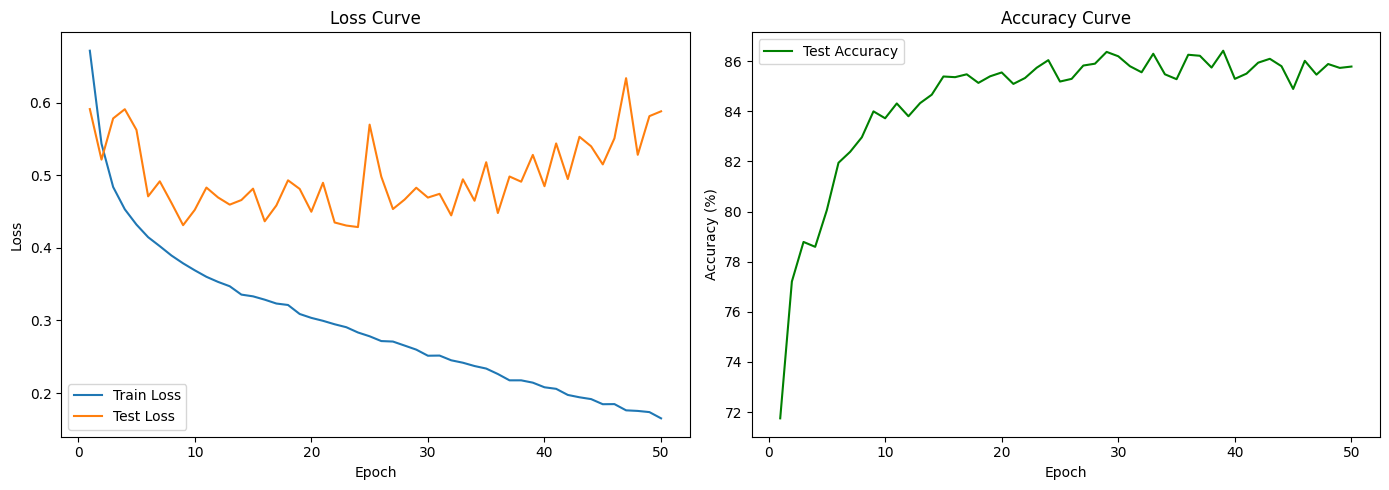

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, 51), history["train_loss"], label="Train Loss")
ax1.plot(range(1, 51), history["test_loss"], label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curve")
ax1.legend()

ax2.plot(range(1, 51),history["test_acc"],label = "Test Accuracy",
         color = "green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Curve")
ax2.legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85      7410
    Positive       0.84      0.89      0.86      7465

    accuracy                           0.86     14875
   macro avg       0.86      0.86      0.86     14875
weighted avg       0.86      0.86      0.86     14875



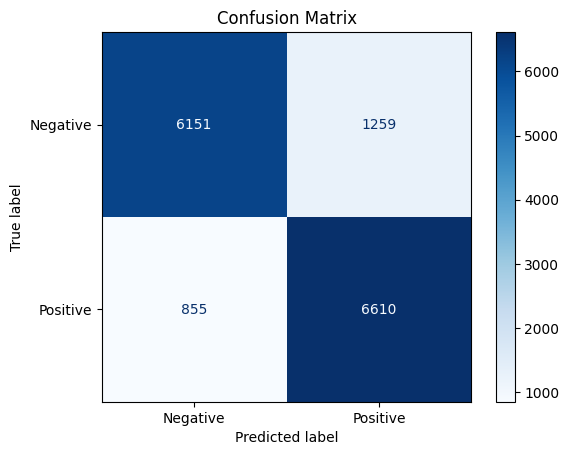

In [ ]:
from sklearn.metrics import (classification_report,confusion_matrix,
                             ConfusionMatrixDisplay)

def full_evaluation(model, test_loader, device):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in test_loader:

            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels,all_preds,
                        target_names = ["Negative", "Positive"]))

    cm = confusion_matrix(all_labels,all_preds)
    disp = ConfusionMatrixDisplay(cm,display_labels = ["Negative","Positive"])
    disp.plot(cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.show()

full_evaluation(model, test_data_loader, device)

In [ ]:
def evaluate_model(model,test_loader,criterion,device):

    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in test_loader:

            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits,dim = 1)
            correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total_samples * 100

    print(f"Test Loss : {avg_loss:.4f}")
    print(f"Test Accuracy : {accuracy:.2f}%")

    return avg_loss,accuracy

In [ ]:
test_loss,test_accuracy = evaluate_model(model,test_data_loader,
                                         criterion,device)

Test Loss : 0.5879
Test Accuracy : 85.79%
